In [1]:
import cftime
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import cartopy.feature as feature
import matplotlib.colors as colors
from cartopy.util import add_cyclic_point
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter)

import matplotlib.patheffects as pe

from scipy import stats

In [2]:
# --- read mask

# input mask - Miocene
ds_mask = xr.open_dataset('../Miocene_LANDFRAC.nc')
var = 'LANDFRAC'
mask = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Mio, lons = add_cyclic_point(mask, coord=ds_mask['lon'])

# ==================================================================
# input mask - Preindustrial
ds_mask = xr.open_dataset('../Preindustrial_LANDFRAC.nc')
var = 'LANDFRAC'
mask = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Pi, lons = add_cyclic_point(mask, coord=ds_mask['lon'])

In [3]:
lat = ds_mask['lat']
lon = ds_mask['lon']
weights = np.cos(np.deg2rad(lat))

## fSST: Surface Temperature & net TOA Radiation anomalies

In [21]:
# --- read data --- 

ds_fSST = xr.open_dataset('./FigS2_fSST_TS_NetTOA.nc')

fSST_Pi_dtoa = ds_fSST['fSST_Pi_toa']      # Net TOA in response to dust changes (PI scenario)
fSST_Pi_dts = ds_fSST['fSST_Pi_ts']        # TS in response to dust changes (PI scenario)

fSST_Mio_dtoa = ds_fSST['fSST_Mio_toa']    # Net TOA in response to dust changes (Mio scenario)
fSST_Mio_dts = ds_fSST['fSST_Mio_ts']      # TS in response to dust changes (Mio scenario)

## FCM: Surface Temperature & net TOA Radiation anomalies
### Anomaly: respect to 2000~2500 yr. of reference case

In [33]:
# --- read data --- 

ds_FCM = xr.open_dataset('./FigS2_FCM_TS_NetTOA_Annual.nc')

FCM_Pi_dtoa = ds_FCM['FCM_Pi_Ano_toa_ANN']      # Net TOA in response to dust changes (PI scenario)
FCM_Pi_dts = ds_FCM['FCM_Pi_Ano_ts_ANN']        # TS in response to dust changes (PI scenario)

FCM_Mio_dtoa = ds_FCM['FCM_Mio_Ano_toa_ANN']    # Net TOA in response to dust changes (Mio scenario)
FCM_Mio_dts = ds_FCM['FCM_Mio_Ano_ts_ANN']      # TS in response to dust changes (Mio scenario)

In [34]:
FCM_Pi_dtoa_10yr = FCM_Pi_dtoa[0:50].copy()
FCM_Mio_dtoa_10yr = FCM_Mio_dtoa[0:50].copy()

tt = 0
while tt < 50:
    i = tt*10
    FCM_Pi_dtoa_10yr[tt] = FCM_Pi_dtoa[i: i+10].mean(dim=['year'])
    FCM_Mio_dtoa_10yr[tt] = FCM_Mio_dtoa[i: i+10].mean(dim=['year'])
    tt += 1

In [35]:
FCM_Pi_dts_10yr = FCM_Pi_dts[0:50].copy()
FCM_Mio_dts_10yr = FCM_Mio_dts[0:50].copy()

tt = 0
while tt < 50:
    i = tt*10
    FCM_Pi_dts_10yr[tt] = FCM_Pi_dts[i: i+10].mean(dim=['year'])
    FCM_Mio_dts_10yr[tt] = FCM_Mio_dts[i: i+10].mean(dim=['year'])
    tt += 1

## Calculate Corrected ERF

In [36]:
# For Miocene Dust ERF (Pi scenario)

x_Pi = FCM_Pi_dts
y_Pi = FCM_Pi_dtoa

p_Pi = np.polyfit(x_Pi[0:30], y_Pi[0:30], 1)
lambda_Pi, yintercept_Pi = p_Pi

fSST_Pi_dtoa_mean = fSST_Pi_dtoa.weighted(weights).mean(dim=['lon','lat']) 
fSST_Pi_dts_mean = fSST_Pi_dts.weighted(weights).mean(dim=['lon','lat']) 

Pi_ERF_corrected = fSST_Pi_dtoa_mean - lambda_Pi*fSST_Pi_dts_mean

print('<< Regional lambda (global temp) --- GeoPi.Dust* >>')
print('ERF= ', f'{fSST_Pi_dtoa_mean.values:.3f}')
print('ΔTland= ', f'{fSST_Pi_dts_mean.values:.3f}')
print('lambda= ', f'{lambda_Pi:.3f}')
print('ERFc= ', f'{Pi_ERF_corrected.values:.3f}')

<< Regional lambda (global temp) --- GeoPi.Dust* >>
ERF=  -0.006
ΔTland=  0.002
lambda=  -1.493
ERFc=  -0.003


In [37]:
# For Miocene Dust ERF (Mio scenario)

x_Mio = FCM_Mio_dts
y_Mio = FCM_Mio_dtoa

p_Mio = np.polyfit(x_Mio[0:30], y_Mio[0:30], 1)
lambda_Mio, yintercept_Mio = p_Mio

fSST_Mio_dtoa_mean = fSST_Mio_dtoa.weighted(weights).mean(dim=['lon','lat']) 
fSST_Mio_dts_mean = fSST_Mio_dts.weighted(weights).mean(dim=['lon','lat']) 

Mio_ERF_corrected = fSST_Mio_dtoa_mean - lambda_Mio*fSST_Mio_dts_mean

print('<< Regional lambda (global temp) --- GeoMio.Dust* >>')
print('ERF= ', f'{fSST_Mio_dtoa_mean.values:.3f}')
print('ΔTland= ', f'{fSST_Mio_dts_mean.values:.3f}')
print('lambda= ', f'{lambda_Mio:.3f}')
print('ERFc= ', f'{Mio_ERF_corrected.values:.3f}')

<< Regional lambda (global temp) --- GeoMio.Dust* >>
ERF=  0.143
ΔTland=  0.012
lambda=  -0.563
ERFc=  0.150


## Gregory Plot

/glade/derecho/scratch/pjchen/tmp/ipykernel_59233/3239874108.py:24: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[0].scatter(FCM_Pi_dts[50:], FCM_Pi_dtoa[50:], c = 'pink', cmap='viridis', marker='o', s=10, zorder=1)
/glade/derecho/scratch/pjchen/tmp/ipykernel_59233/3239874108.py:25: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[0].scatter(FCM_Pi_dts[0:30], FCM_Pi_dtoa[0:30], c = 'deeppink', cmap='viridis', marker='o', s=10, zorder=2)
/glade/derecho/scratch/pjchen/tmp/ipykernel_59233/3239874108.py:117: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[1].scatter(-FCM_Mio_dts[50:], -FCM_Mio_dtoa[50:], c = 'skyblue', cmap='viridis', marker='o', s=10, zorder=1)
/glade/derecho/scratch/pjchen/tmp/ipykernel_59233/3239874108.py:118: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[1].scatter(-FCM_Mio_dts

Text(0.5, 1.0, 'Feedback Parameters ($\\lambda$)')

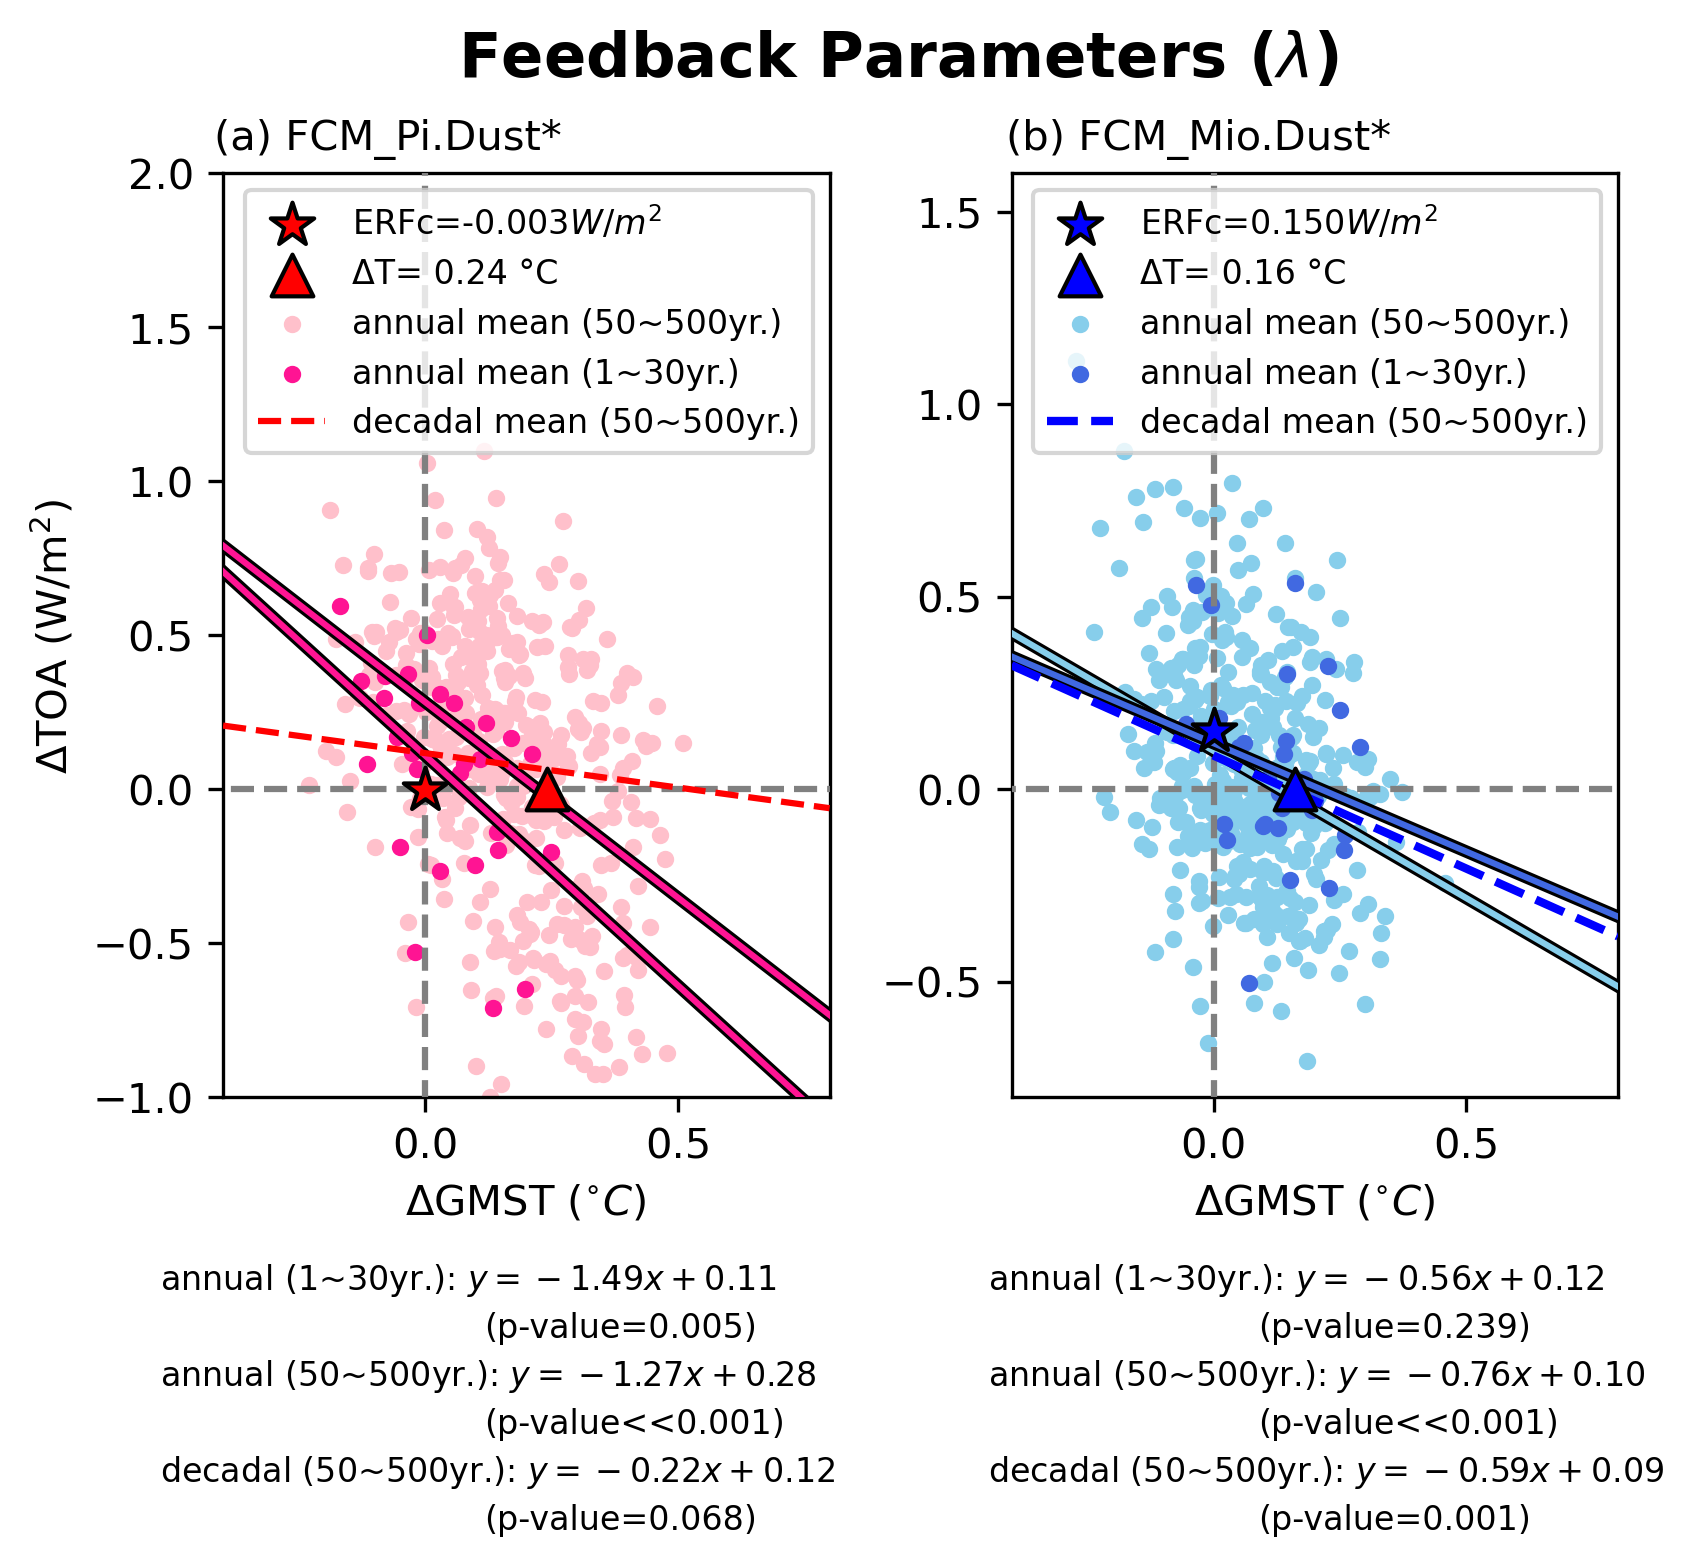

In [38]:
fig, axs = plt.subplots(1, 2, figsize=(6, 4), dpi=300)
fig.subplots_adjust(wspace=0.3, hspace=0.05) 

# --- GeoPi_MioDust ---
axs[0].scatter(0, Pi_ERF_corrected.values, c = 'red', marker='*', s=120, edgecolors='black', linewidths=1.0, zorder=7)
axs[0].scatter(0.24, 0, c = 'red', marker='^', s=100, edgecolors='black', linewidths=1.0, zorder=7)    # ΔT obtained from Fig5a

# Calculate the regression line
x_Pi_first30 = FCM_Pi_dts[0:30]
y_Pi_first30 = FCM_Pi_dtoa[0:30]
p_Pi_first30 = np.polyfit(x_Pi_first30, y_Pi_first30, 1)
lambda_Pi_first30, yintercept_Pi_first30 = p_Pi_first30

x_Pi_after50 = FCM_Pi_dts[50:]
y_Pi_after50 = FCM_Pi_dtoa[50:]
p_Pi_after50 = np.polyfit(x_Pi_after50, y_Pi_after50, 1)
lambda_Pi_after50, yintercept_Pi_after50 = p_Pi_after50

x_Pi_after50_10yr = FCM_Pi_dts_10yr[5:]
y_Pi_after50_10yr = FCM_Pi_dtoa_10yr[5:]
p_Pi_after50_10yr = np.polyfit(x_Pi_after50_10yr, y_Pi_after50_10yr, 1)
lambda_Pi_after50_10yr, yintercept_Pi_after50_10yr = p_Pi_after50_10yr

axs[0].scatter(FCM_Pi_dts[50:], FCM_Pi_dtoa[50:], c = 'pink', cmap='viridis', marker='o', s=10, zorder=1)
axs[0].scatter(FCM_Pi_dts[0:30], FCM_Pi_dtoa[0:30], c = 'deeppink', cmap='viridis', marker='o', s=10, zorder=2)
axs[0].axline(xy1=(0, yintercept_Pi_after50_10yr), slope=lambda_Pi_after50_10yr, 
              label=f'$y = {lambda_Pi_after50_10yr:.2f}x {yintercept_Pi_after50_10yr:+.2f}$', color='red', linestyle='--', linewidth=1.5, zorder=6)

line_Pi_first30 = axs[0].axline(xy1=(0, yintercept_Pi_first30), slope=lambda_Pi_first30, 
                                label=f'$y = {lambda_Pi_first30:.2f}x {yintercept_Pi_first30:+.2f}$', color='deeppink', linestyle='-', zorder=5)
line_Pi_after50 = axs[0].axline(xy1=(0, yintercept_Pi_after50), slope=lambda_Pi_after50, 
                                label=f'$y = {lambda_Pi_after50:.2f}x {yintercept_Pi_after50:+.2f}$', color='deeppink', linestyle='-', zorder=5)
line_Pi_first30.set_path_effects([pe.Stroke(linewidth=3.0, foreground='black'),pe.Normal()])
line_Pi_after50.set_path_effects([pe.Stroke(linewidth=3.0, foreground='black'),pe.Normal()])

axs[0].set_xlim([-0.4, 0.8])
axs[0].set_ylim([-1.0, 2.0])
axs[0].set_xlabel('ΔGMST ($^{\circ}C$)')
axs[0].set_ylabel('ΔTOA (W/m$^{2}$)')

axs[0].plot([-3,3], [0,0], "grey", linestyle='--', zorder=3)
axs[0].plot([0,0], [-3, 2.0], "grey", linestyle='--', zorder=3)

# Estimate p-value
y_Pi_first30_pred = np.polyval(p_Pi_first30, x_Pi_first30)
y_Pi_first30_res = y_Pi_first30 - y_Pi_first30_pred
dof_Pi_first30 = len(x_Pi_first30) - 2         # degree of freedom   
y_Pi_first30_res_std_error = np.sqrt(np.sum(y_Pi_first30_res**2) / dof_Pi_first30)
y_Pi_first30_slope_std_error = y_Pi_first30_res_std_error / np.sqrt(np.sum((x_Pi_first30 - np.mean(x_Pi_first30))**2))
y_Pi_first30_t_stat = lambda_Pi_first30 / y_Pi_first30_slope_std_error
y_Pi_first30_pvalue = 2 * (1 - stats.t.cdf(np.abs(y_Pi_first30_t_stat), df=dof_Pi_first30))

y_Pi_after50_pred = np.polyval(p_Pi_after50, x_Pi_after50)
y_Pi_after50_res = y_Pi_after50 - y_Pi_after50_pred
dof_Pi_after50 = len(x_Pi_after50) - 2     
y_Pi_after50_res_std_error = np.sqrt(np.sum(y_Pi_after50_res**2) / dof_Pi_after50)
y_Pi_after50_slope_std_error = y_Pi_after50_res_std_error / np.sqrt(np.sum((x_Pi_after50 - np.mean(x_Pi_after50))**2))
y_Pi_after50_t_stat = lambda_Pi_after50 / y_Pi_after50_slope_std_error
y_Pi_after50_pvalue = 2 * (1 - stats.t.cdf(np.abs(y_Pi_after50_t_stat), df=dof_Pi_after50))

y_Pi_after50_10yr_pred = np.polyval(p_Pi_after50_10yr, x_Pi_after50_10yr)
y_Pi_after50_10yr_res = y_Pi_after50_10yr - y_Pi_after50_10yr_pred
dof_Pi_after50_10yr = len(x_Pi_after50_10yr) - 2  
y_Pi_after50_10yr_res_std_error = np.sqrt(np.sum(y_Pi_after50_10yr_res**2) / dof_Pi_after50_10yr)
y_Pi_after50_10yr_slope_std_error = y_Pi_after50_10yr_res_std_error / np.sqrt(np.sum((x_Pi_after50_10yr - np.mean(x_Pi_after50_10yr))**2))
y_Pi_after50_10yr_t_stat = lambda_Pi_after50_10yr / y_Pi_after50_10yr_slope_std_error
y_Pi_after50_10yr_pvalue = 2 * (1 - stats.t.cdf(np.abs(y_Pi_after50_10yr_t_stat), df=dof_Pi_after50_10yr))

plt.figtext(0.12,0.9,'(a) FCM_Pi.Dust*',ha='left',fontsize=10)

text_Pi_first30 = 'annual (1~30yr.): '+ f'$y = {lambda_Pi_first30:.2f}x {yintercept_Pi_first30:+.2f}$'
text_Pi_after50 = 'annual (50~500yr.): '+ f'$y = {lambda_Pi_after50:.2f}x {yintercept_Pi_after50:+.2f}$'
text_Pi_after50_10yr = 'decadal (50~500yr.): '+ f'$y = {lambda_Pi_after50_10yr:.2f}x {yintercept_Pi_after50_10yr:+.2f}$'
pvalue_Pi_first30 = ' (p-value='+str('{:03.3f}'.format(y_Pi_first30_pvalue))+')'
pvalue_Pi_after50 = ' (p-value='+str('{:03.3f}'.format(y_Pi_after50_pvalue))+')'
pvalue_Pi_after50_10yr = ' (p-value='+str('{:03.3f}'.format(y_Pi_after50_10yr_pvalue))+')'

plt.figtext(0.09,-0.05,text_Pi_first30,ha='left',fontsize=8)
plt.figtext(0.27,-0.09,'(p-value='+str('{:03.3f}'.format(y_Pi_first30_pvalue))+')',ha='left',fontsize=8)
plt.figtext(0.09,-0.13,text_Pi_after50,ha='left',fontsize=8)
# plt.figtext(0.27,-0.17,'(p-value='+str('{:03.3f}'.format(y_Pi_after50_pvalue))+')',ha='left',fontsize=8)
plt.figtext(0.27,-0.17,'(p-value<<0.001)',ha='left',fontsize=8)
plt.figtext(0.09,-0.21,text_Pi_after50_10yr,ha='left',fontsize=8)
plt.figtext(0.27,-0.25,'(p-value='+str('{:03.3f}'.format(y_Pi_after50_10yr_pvalue))+')',ha='left',fontsize=8)

legend_Pi_ERF = 'ERFc='+f'{Pi_ERF_corrected.values:.3f}'+'$W/m^2$'
legend_Pi_T = 'ΔT= 0.24 °C'
legend_Pi_first30 = 'annual mean (1~30yr.)'
legend_Pi_after50 = 'annual mean (50~500yr.)'
legend_Pi_after50_10yr = 'decadal mean (50~500yr.)'
legend = [legend_Pi_ERF, legend_Pi_T, legend_Pi_after50, legend_Pi_first30, legend_Pi_after50_10yr]
axs[0].legend(legend, fontsize=8)

# ===============================================================================
# --- GeoMio_PiDust ---

axs[1].scatter(0, Mio_ERF_corrected.values, c = 'blue', marker='*', s=120, edgecolors='black', linewidths=1.0, zorder=7)
axs[1].scatter(0.16, 0, c = 'blue', marker='^', s=100, edgecolors='black', linewidths=1.0, zorder=7)       # ΔT obtained from Fig5b

# Calculate the regression line
x_Mio_first30 = -FCM_Mio_dts[0:30]
y_Mio_first30 = -FCM_Mio_dtoa[0:30]
p_Mio_first30 = np.polyfit(x_Mio_first30, y_Mio_first30, 1)
lambda_Mio_first30, yintercept_Mio_first30 = p_Mio_first30

x_Mio_after50 = -FCM_Mio_dts[50:]
y_Mio_after50 = -FCM_Mio_dtoa[50:]
p_Mio_after50 = np.polyfit(x_Mio_after50, y_Mio_after50, 1)
lambda_Mio_after50, yintercept_Mio_after50 = p_Mio_after50

x_Mio_after50_10yr = -FCM_Mio_dts_10yr[5:]
y_Mio_after50_10yr = -FCM_Mio_dtoa_10yr[5:]
p_Mio_after50_10yr = np.polyfit(x_Mio_after50_10yr, y_Mio_after50_10yr, 1)
lambda_Mio_after50_10yr, yintercept_Mio_after50_10yr = p_Mio_after50_10yr


axs[1].scatter(-FCM_Mio_dts[50:], -FCM_Mio_dtoa[50:], c = 'skyblue', cmap='viridis', marker='o', s=10, zorder=1)
axs[1].scatter(-FCM_Mio_dts[0:30], -FCM_Mio_dtoa[0:30], c = 'royalblue', cmap='viridis', marker='o', s=10, zorder=2)
axs[1].axline(xy1=(0, yintercept_Mio_after50_10yr), slope=lambda_Mio_after50_10yr, 
              label=f'$y = {lambda_Mio_after50_10yr:.2f}x {yintercept_Mio_after50_10yr:+.2f}$', color='blue', linestyle='--', linewidth=2.0, zorder=6)

line_Mio_first30 = axs[1].axline(xy1=(0, yintercept_Mio_first30), slope=lambda_Mio_first30, 
                                 label=f'$y = {lambda_Mio_first30:.2f}x {yintercept_Mio_first30:+.2f}$', color='royalblue', linestyle='-', zorder=5)
line_Mio_after50 = axs[1].axline(xy1=(0, yintercept_Mio_after50), slope=lambda_Mio_after50, 
                                 label=f'$y = {lambda_Mio_after50:.2f}x {yintercept_Mio_after50:+.2f}$', color='skyblue', linestyle='-', zorder=4)
line_Mio_first30.set_path_effects([pe.Stroke(linewidth=3.0, foreground='black'),pe.Normal()])
line_Mio_after50.set_path_effects([pe.Stroke(linewidth=3.0, foreground='black'),pe.Normal()])


axs[1].set_xlim([-0.4, 0.8])
axs[1].set_ylim([-0.8, 1.6])
axs[1].set_xlabel('ΔGMST ($^{\circ}C$)')
axs[1].set_ylabel('')

axs[1].plot([-3,3], [0,0], "grey", linestyle='--', zorder=3)
axs[1].plot([0,0], [-3, 2.0], "grey", linestyle='--', zorder=3)


# Estimate p-value
y_Mio_first30_pred = np.polyval(p_Mio_first30, x_Mio_first30)
y_Mio_first30_res = y_Mio_first30 - y_Mio_first30_pred
dof_Mio_first30 = len(x_Mio_first30) - 2         # degree of freedom   
y_Mio_first30_res_std_error = np.sqrt(np.sum(y_Mio_first30_res**2) / dof_Mio_first30)
y_Mio_first30_slope_std_error = y_Mio_first30_res_std_error / np.sqrt(np.sum((x_Mio_first30 - np.mean(x_Mio_first30))**2))
y_Mio_first30_t_stat = lambda_Mio_first30 / y_Mio_first30_slope_std_error
y_Mio_first30_pvalue = 2 * (1 - stats.t.cdf(np.abs(y_Mio_first30_t_stat), df=dof_Mio_first30))

y_Mio_after50_pred = np.polyval(p_Mio_after50, x_Mio_after50)
y_Mio_after50_res = y_Mio_after50 - y_Mio_after50_pred
dof_Mio_after50 = len(x_Mio_after50) - 2     
y_Mio_after50_res_std_error = np.sqrt(np.sum(y_Mio_after50_res**2) / dof_Mio_after50)
y_Mio_after50_slope_std_error = y_Mio_after50_res_std_error / np.sqrt(np.sum((x_Mio_after50 - np.mean(x_Mio_after50))**2))
y_Mio_after50_t_stat = lambda_Mio_after50 / y_Mio_after50_slope_std_error
y_Mio_after50_pvalue = 2 * (1 - stats.t.cdf(np.abs(y_Mio_after50_t_stat), df=dof_Mio_after50))

y_Mio_after50_10yr_pred = np.polyval(p_Mio_after50_10yr, x_Mio_after50_10yr)
y_Mio_after50_10yr_res = y_Mio_after50_10yr - y_Mio_after50_10yr_pred
dof_Mio_after50_10yr = len(x_Mio_after50_10yr) - 2  
y_Mio_after50_10yr_res_std_error = np.sqrt(np.sum(y_Mio_after50_10yr_res**2) / dof_Mio_after50_10yr)
y_Mio_after50_10yr_slope_std_error = y_Mio_after50_10yr_res_std_error / np.sqrt(np.sum((x_Mio_after50_10yr - np.mean(x_Mio_after50_10yr))**2))
y_Mio_after50_10yr_t_stat = lambda_Mio_after50_10yr / y_Mio_after50_10yr_slope_std_error
y_Mio_after50_10yr_pvalue = 2 * (1 - stats.t.cdf(np.abs(y_Mio_after50_10yr_t_stat), df=dof_Mio_after50_10yr))
                            
plt.figtext(0.56,0.9,'(b) FCM_Mio.Dust*',ha='left',fontsize=10)

text_Mio_first30 = 'annual (1~30yr.): '+ f'$y = {lambda_Mio_first30:.2f}x {yintercept_Mio_first30:+.2f}$'
text_Mio_after50 = 'annual (50~500yr.): '+ f'$y = {lambda_Mio_after50:.2f}x {yintercept_Mio_after50:+.2f}$'
text_Mio_after50_10yr = 'decadal (50~500yr.): '+ f'$y = {lambda_Mio_after50_10yr:.2f}x {yintercept_Mio_after50_10yr:+.2f}$'
pvalue_Mio_first30 = ' (p-value='+str('{:03.3f}'.format(y_Mio_first30_pvalue))+')'
pvalue_Mio_after50 = ' (p-value='+str('{:03.3f}'.format(y_Mio_after50_pvalue))+')'
pvalue_Mio_after50_10yr = ' (p-value='+str('{:03.3f}'.format(y_Mio_after50_10yr_pvalue))+')'

plt.figtext(0.55,-0.05,text_Mio_first30,ha='left',fontsize=8)
plt.figtext(0.7,-0.09,'(p-value='+str('{:03.3f}'.format(y_Mio_first30_pvalue))+')',ha='left',fontsize=8)
plt.figtext(0.55,-0.13,text_Mio_after50,ha='left',fontsize=8)
# plt.figtext(0.7,-0.17,'(p-value='+str('{:03.3f}'.format(y_Mio_after50_pvalue))+')',ha='left',fontsize=8)
plt.figtext(0.7,-0.17,'(p-value<<0.001)',ha='left',fontsize=8)
plt.figtext(0.55,-0.21,text_Mio_after50_10yr,ha='left',fontsize=8)
plt.figtext(0.7,-0.25,'(p-value='+str('{:03.3f}'.format(y_Mio_after50_10yr_pvalue))+')',ha='left',fontsize=8)

legend_Mio_ERF = 'ERFc='+f'{Mio_ERF_corrected.values:.3f}'+'$W/m^2$'
legend_Mio_T = 'ΔT= 0.16 °C'
legend_Mio_first30 = 'annual mean (1~30yr.)'
legend_Mio_after50 = 'annual mean (50~500yr.)'
legend_Mio_after50_10yr = 'decadal mean (50~500yr.)'
legend = [legend_Mio_ERF, legend_Mio_T, legend_Mio_after50, legend_Mio_first30, legend_Mio_after50_10yr]
axs[1].legend(legend, fontsize=8)

plt.suptitle('Feedback Parameters ($\lambda$)', y=1.0, fontsize=15, weight='bold')